# 15 — Problem-Solving: Interest, Mixture, Uniform Motion, Constant-Rate Job Applications

**Equations and Inequalities ▸ 7.** This is the topic that finally **uses** everything we
built. Until now the equations were handed to us. Here the equation is **hidden inside a
story in words**, and the real skill is **translation**: turn English into algebra, solve,
then read the answer back into the story — and check it makes sense.

Mental picture: a word problem is a locked box. The *key* is always the same five-step
routine. Once you name the unknown and find the **one sentence that balances** (money in =
money out, pure stuff in = pure stuff out, distances match, work done = 1 whole job), the
equation writes itself.

We study the four classic families:
- **Interest** — money grows at a rate; $I = Prt$.
- **Mixture** — blend things of different strengths/prices; the *amount of pure stuff* is
  conserved.
- **Uniform motion** — constant speed; $d = rt$.
- **Constant-rate jobs (work)** — people/machines work at steady rates that **add up**.

**Why it matters for AI.** This *is* mathematical modelling — the exact move a data
scientist makes turning a real question into equations a computer can solve. Two ideas here
are deep: **rates add** (work rates, closing speeds) is linearity, the heart of linear
algebra and neural layers; and a **mixture is a weighted average** (a convex combination),
which is exactly how expectation, ensembles, and attention weights combine things. Also the
"**check the answer against the real situation**" habit is model validation.

## Quick recall (spaced repetition)
From session 14 (Absolute Value). Solutions at the **end of §1**.

1. Solve $|2x - 1| < 5$. Give interval notation.
2. Solve $|x - 2| \ge 3$. (Is this one interval or two rays?)
3. **(older, topic 12)** Solve $\sqrt{x+2} = x$ and reject any extraneous root.

## What we cover today
1. The **five-step translation routine** (the key to every word problem).
2. **Interest** ($I=Prt$) and split-investment problems.
3. **Mixture** problems (the conservation-of-pure-amount idea, proved).
4. **Uniform motion** ($d=rt$): same/opposite directions, upstream/downstream.
5. **Constant-rate job** problems: why **rates add**, and $\frac1{t_1}+\frac1{t_2}=\frac1t$
   (proved).
6. Python: `sympy` to solve each model symbolically, plus a plot of two people's combined
   work rate.

## 1. The five-step routine, and the model formulas

Every problem below is solved the **same way**. Memorise this routine, not the individual
problems.

> **The five steps.**
> 1. **Name** the unknown with a letter, and write down its **units** (dollars, litres, mph,
>    hours). Often name the quantity the question asks for.
> 2. **Express** every other quantity in the story in terms of that letter.
> 3. **Find the balancing sentence** — the one fact that says two things are equal
>    (total = sum of parts, distances meet, one whole job) — and write it as an **equation**.
> 4. **Solve** the equation with the algebra from earlier topics.
> 5. **Check** the answer *in the words of the problem* (not just the equation), and state it
>    with units. Reject answers that are impossible (negative length, speed, time).

Now the four model formulas, each with the idea behind it.

> **Simple interest.** If a principal (starting amount) $P$ earns at annual rate $r$ (a
> decimal, so $5\%=0.05$) for time $t$ years, the **interest** earned is
> $$ I = P\,r\,t. $$
> Reason: each year you earn a fraction $r$ of $P$, i.e. $Pr$ per year; over $t$ years that
> is $Prt$. The total value is $P+I = P(1+rt)$.

> **Mixture / concentration.** In a solution, the **amount of pure substance** equals
> $(\text{concentration})\times(\text{total amount})$. When you pour solutions together, the
> pure amounts **add**:
> $$ c_1 V_1 + c_2 V_2 = c_{\text{mix}}\,(V_1+V_2). $$
> The same shape works for money: (price per unit)×(quantity) adds up to total value.

> **Uniform (constant-speed) motion.** Distance = rate × time:
> $$ d = r\,t. $$
> If two objects move, you usually match a distance or a time. Speeds **combine**: moving
> **toward** each other the gap closes at $r_1+r_2$; **same direction**, the faster gains at
> $r_1-r_2$; a boat in a current is $r_{\text{boat}}+r_{\text{current}}$ downstream and
> $r_{\text{boat}}-r_{\text{current}}$ upstream.

> **Constant-rate job (work).** If a job takes $T$ hours, the **work rate** is $\frac1T$ of
> the job per hour. Rates of workers **add**. Together they finish in time $t$ where
> $$ \frac1{t_1}+\frac1{t_2}=\frac1t. $$

## 2. Two small theorems (the ideas that make the formulas true)

Most of this topic is modelling, not deep proof — but two "obvious" formulas deserve a real
justification, because their logic (**rates add**, **amounts are conserved**) is exactly the
part people get wrong.

### Theorem 1 (combined work rate)
Suppose worker $A$ can finish a whole job alone in $t_1$ hours and worker $B$ alone in $t_2$
hours, each working at a **constant** rate. Working together (rates independent, no
interference), they finish in time $t$ given by
$$ \frac1{t_1}+\frac1{t_2}=\frac1t,\qquad\text{equivalently}\qquad t=\frac{t_1 t_2}{t_1+t_2}. $$

**Proof.** "Constant rate, whole job in $t_1$ hours" means $A$ completes a **fraction**
$\frac1{t_1}$ of the job per hour (in $h$ hours, $A$ does $\frac{h}{t_1}$ of the job, and at
$h=t_1$ that is $1$ whole job). Likewise $B$ does $\frac1{t_2}$ per hour. In one hour
together they complete $\frac1{t_1}+\frac1{t_2}$ of the job — this **addition of rates** is
the key modelling assumption (their efforts do not overlap or block each other). Let $t$ be
the time to finish one whole job together. Then rate $\times$ time $=$ work:
$$ \Big(\frac1{t_1}+\frac1{t_2}\Big)\,t = 1 \ \Longrightarrow\ \frac1t=\frac1{t_1}+\frac1{t_2}. $$
Combine over a common denominator (topic 7): $\frac1t=\frac{t_2+t_1}{t_1t_2}$, so
$t=\frac{t_1t_2}{t_1+t_2}$. $\qquad\blacksquare$

**Sanity checks.** If $t_1=t_2=T$: $t=\frac{T^2}{2T}=\frac T2$ — two equal workers take half
the time. ✓ And $t$ is always **smaller** than both $t_1,t_2$ (more help ⇒ faster). ✓

### Theorem 2 (conservation of the pure amount in a mixture)
If solution 1 has volume $V_1$ at concentration $c_1$ and solution 2 has volume $V_2$ at
concentration $c_2$, and you mix them with **no gain or loss** of pure substance, the mixture
concentration is the **weighted average**
$$ c_{\text{mix}}=\frac{c_1V_1+c_2V_2}{V_1+V_2}, $$
a number **between** $c_1$ and $c_2$.

**Proof.** "Concentration $c$ in volume $V$" means the pure-substance amount is $cV$ (that is
the definition of concentration = pure per total). Nothing is created or destroyed by
pouring, so the pure amount of the mix is $c_1V_1+c_2V_2$, in total volume $V_1+V_2$. Its
concentration is pure$\div$total $=\frac{c_1V_1+c_2V_2}{V_1+V_2}$. Because it is a weighted
average with positive weights $V_1,V_2$, it lies between $\min(c_1,c_2)$ and
$\max(c_1,c_2)$. $\qquad\blacksquare$

*(This "weighted average lies between the parts" is a **convex combination** — the same fact
behind expected value, model ensembles, and attention weights in AI.)*

### Recall-quiz solutions (from the top)
1. $|2x-1|<5\iff-5<2x-1<5\iff-2<x<3$, i.e. $(-2,3)$.
2. $|x-2|\ge3\iff x-2\ge3$ or $x-2\le-3\iff x\ge5$ or $x\le-1$: **two rays**,
   $(-\infty,-1]\cup[5,\infty)$.
3. Square: $x+2=x^2\Rightarrow(x-2)(x+1)=0$; $x=2$ checks ($\sqrt4=2$), $x=-1$ is extraneous
   ($\sqrt1=1\ne-1$). Answer $x=2$.

## 3. Worked examples (watch the five steps)

**Example A — split investment (interest).** You invest \$10{,}000, part at $4\%$ and the
rest at $7\%$ simple annual interest. After one year the total interest is \$610. How much is
at each rate?
- **Name:** let $x$ = dollars invested at $4\%$. Then $10000-x$ is at $7\%$.
- **Balance:** interest$_{4\%}$ + interest$_{7\%}$ = 610, with $t=1$:
  $0.04x + 0.07(10000-x) = 610$.
- **Solve:** $0.04x + 700 - 0.07x = 610 \Rightarrow -0.03x = -90 \Rightarrow x = 3000$.
- **Answer:** \$3000 at $4\%$ and \$7000 at $7\%$. **Check:** $0.04(3000)+0.07(7000)=120+490=610$ ✓.

**Example B — mixture (concentration).** How many litres of a $20\%$ acid solution must you
add to $5\,$L of a $50\%$ solution to get a $30\%$ solution?
- **Name:** $x$ = litres of the $20\%$ solution added.
- **Balance (pure acid, Theorem 2):** $0.20x + 0.50(5) = 0.30(x+5)$.
- **Solve:** $0.20x + 2.5 = 0.30x + 1.5 \Rightarrow 1.0 = 0.10x \Rightarrow x = 10$.
- **Answer:** add $10\,$L. **Check:** pure acid $=0.2(10)+0.5(5)=2+2.5=4.5$; total $=15$ L;
  $4.5/15=0.30$ ✓.

**Example C — uniform motion, opposite directions.** Two trains leave the same station going
opposite ways, one at $60\,$mph and one at $75\,$mph. After how long are they $270\,$mi apart?
- **Name:** $t$ = hours.
- **Balance:** distances add (moving apart): $60t + 75t = 270$.
- **Solve:** $135t = 270 \Rightarrow t = 2$. **Answer:** $2$ hours. **Check:** $120+150=270$ ✓.

**Example D — uniform motion, upstream/downstream (rational).** A boat goes $12\,$mi
downstream in the same time it goes $8\,$mi upstream. The current is $2\,$mph. Find the boat's
speed $b$ in still water.
- **Name:** $b$ = boat speed (mph). Downstream speed $b+2$, upstream $b-2$.
- **Balance (equal times, $t=d/r$):** $\dfrac{12}{b+2} = \dfrac{8}{b-2}$.
- **Solve (cross-multiply, both denominators $\ne0$):**
  $12(b-2) = 8(b+2) \Rightarrow 12b-24 = 8b+16 \Rightarrow 4b = 40 \Rightarrow b = 10$.
- **Answer:** $10\,$mph. **Check:** down $12/12=1$ h, up $8/8=1$ h — equal ✓. (Reject $b\le2$,
  which would make upstream speed $\le0$.)

**Example E — combined work (Theorem 1).** Pipe $A$ fills a tank in $6\,$h, pipe $B$ in
$4\,$h. How long together?
- **Balance:** $\dfrac16 + \dfrac14 = \dfrac1t$.
- **Solve:** $\dfrac{2}{12}+\dfrac{3}{12}=\dfrac{5}{12}=\dfrac1t \Rightarrow t=\dfrac{12}{5}=2.4$ h.
- **Answer:** $2.4$ hours ($2$ h $24$ min). **Check:** in $2.4$ h, $A$ does $2.4/6=0.4$, $B$
  does $2.4/4=0.6$; $0.4+0.6=1$ whole tank ✓.

**Example F — a quadratic application.** A rectangular garden is $3\,$m longer than it is
wide, with area $40\,$m². Find its dimensions.
- **Name:** $w$ = width (m); length $= w+3$.
- **Balance:** $w(w+3)=40 \Rightarrow w^2+3w-40=0 \Rightarrow (w+8)(w-5)=0$.
- **Solve:** $w=5$ or $w=-8$. **Reject $w=-8$** (width can't be negative). **Answer:**
  width $5\,$m, length $8\,$m. **Check:** $5\times8=40$ ✓.

## 4. Python demonstrations

`sympy` is perfect here: define the unknown, write the **balancing equation** exactly as in
the five-step routine, and let `solve` do the algebra. The point is that the hard part is
*setting up* the equation — the solving is mechanical.

In [1]:
import sympy as sp

# Example A: split investment.  x dollars at 4%, (10000-x) at 7%, total interest 610.
x = sp.symbols('x')
eqA = sp.Eq(0.04*x + 0.07*(10000 - x), 610)     # the balancing sentence
solA = sp.solve(eqA, x)
print("A: at 4% =", solA[0], " at 7% =", 10000 - solA[0])   # 3000 and 7000

A: at 4% = 3000.00000000000  at 7% = 7000.00000000000


In [2]:
# Example B: mixture. x litres of 20% added to 5 L of 50% to get 30%.
import sympy as sp
x = sp.symbols('x', positive=True)              # a volume must be positive
eqB = sp.Eq(0.20*x + 0.50*5, 0.30*(x + 5))      # pure acid conserved (Theorem 2)
print("B: litres of 20% to add =", sp.solve(eqB, x))        # [10]

B: litres of 20% to add = [10.0000000000000]


In [3]:
# Example C & D: uniform motion.
import sympy as sp

t = sp.symbols('t', positive=True)
print("C: hours until 270 mi apart =", sp.solve(sp.Eq(60*t + 75*t, 270), t))   # [2]

b = sp.symbols('b', positive=True)              # boat speed in still water
eqD = sp.Eq(12/(b + 2), 8/(b - 2))              # equal times downstream/upstream
sols = sp.solve(eqD, b)
print("D: boat speed candidates =", sols, "-> keep b>2:", [s for s in sols if s > 2])

C: hours until 270 mi apart = [2]
D: boat speed candidates = [10] -> keep b>2: [10]


In [4]:
# Example E: combined work rate (Theorem 1), plus the closed form t = t1*t2/(t1+t2).
import sympy as sp
t = sp.symbols('t', positive=True)
t1, t2 = 6, 4
eqE = sp.Eq(sp.Rational(1, t1) + sp.Rational(1, t2), 1/t)
tog = sp.solve(eqE, t)[0]
print("E: together time =", tog, "hours =", float(tog), "h")          # 12/5 = 2.4
print("   closed form t1*t2/(t1+t2) =", sp.Rational(t1*t2, t1 + t2))  # 12/5  (matches)

E: together time = 12/5 hours = 2.4 h
   closed form t1*t2/(t1+t2) = 12/5


In [5]:
# Example F: quadratic application; reject the impossible (negative) root.
import sympy as sp
w = sp.symbols('w', real=True)
roots = sp.solve(sp.Eq(w*(w + 3), 40), w)
print("F: width candidates =", roots)                       # [-8, 5]
good = [r for r in roots if r > 0]                          # a width must be positive
print("   width =", good[0], "m, length =", good[0] + 3, "m")   # 5 by 8

F: width candidates = [-8, 5]
   width = 5 m, length = 8 m


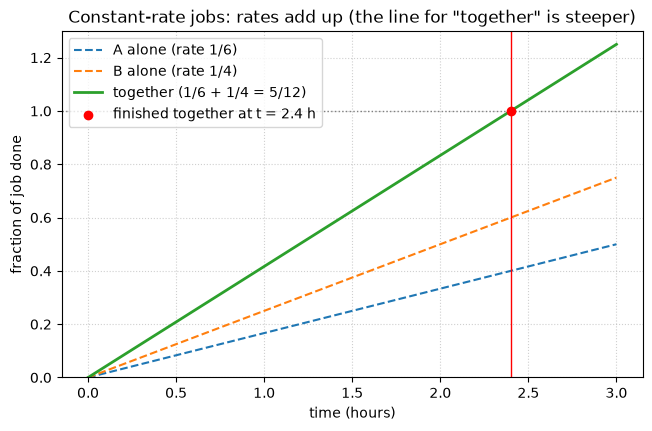

In [6]:
# AI-flavoured picture: RATES ADD.  Combined completion of pipes A (6h) and B (4h).
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 3, 300)
A = t/6            # fraction of the tank filled by A alone after t hours (rate 1/6)
B = t/4            # by B alone (rate 1/4)
together = A + B   # rates add -> combined fraction filled

plt.figure(figsize=(7.5, 4.5))
plt.plot(t, A, '--', label='A alone (rate 1/6)')
plt.plot(t, B, '--', label='B alone (rate 1/4)')
plt.plot(t, together, lw=2, label='together (1/6 + 1/4 = 5/12)')
plt.axhline(1, color='gray', lw=1, ls=':')             # y = 1 means "one whole tank"
plt.axvline(2.4, color='red', lw=1)                    # they finish together at t = 2.4 h
plt.scatter([2.4], [1], color='red', zorder=5, label='finished together at t = 2.4 h')
plt.xlabel('time (hours)'); plt.ylabel('fraction of job done')
plt.title('Constant-rate jobs: rates add up (the line for "together" is steeper)')
plt.legend(); plt.grid(True, ls=':', alpha=0.6); plt.ylim(0, 1.3)
plt.show()

## 5. Exercises (fill in the cells yourself)

For **each** problem: name the unknown with units, write the balancing equation, solve, and
**check in words** (reject impossible answers). Then verify with `sympy`. Easy $\to$ hard.

**Interest**
1. \$8000 is invested at $6\%$ simple interest. How much interest after $3$ years?
2. You split \$12{,}000 between a $5\%$ and an $8\%$ account; after one year you earn \$810
   total. How much is in each?
3. How much must you invest at $4.5\%$ simple interest to earn \$900 in one year?

**Mixture**
4. How many litres of pure water must be added to $6\,$L of a $40\%$ salt solution to make it
   $15\%$?
5. A grocer mixes nuts worth \$6/lb with nuts worth \$9/lb to make $30\,$lb worth \$7/lb.
   How many pounds of each?
6. How many millilitres of a $10\%$ and a $25\%$ solution give $300\,$mL of a $20\%$ solution?

**Uniform motion**
7. Two cyclists start $84\,$mi apart and ride **toward** each other at $12$ and $16\,$mph.
   When do they meet?
8. A plane flies $1500\,$mi with a $50\,$mph tailwind in the same time it flies $1200\,$mi
   against it. Find the plane's still-air speed.
9. You drive to a town at $50\,$mph and return at $30\,$mph; the round trip takes $4$ hours.
   How far away is the town?

**Constant-rate jobs**
10. Alice paints a room in $5\,$h, Bob in $3\,$h. How long together?
11. A tap fills a tub in $20\,$min; the drain empties it in $30\,$min. If both are open, how
    long to fill? (Hint: the drain is a **negative** rate.)
12. Working together two machines finish in $4\,$h. One alone takes $6\,$h. How long for the
    other alone?

**Mixed / harder**
13. A number plus twice its reciprocal is $\tfrac{11}{3}$. Find the number(s).
14. A rectangle's length is $2\,$m more than its width and its area is $63\,$m². Find its
    dimensions.
15. \$5000 is split into two simple-interest accounts, one at $3\%$ and one at $x\%$; total
    one-year interest is \$260 with \$2000 in the $3\%$ account. Find $x$.
16. A boat travels $30\,$mi downstream and back in $8\,$h; the current is $2\,$mph. Find the
    boat's still-water speed. (Sets up a rational $\to$ quadratic equation.)

**Reasoning / proofs**
17. **Derive** $t=\dfrac{t_1t_2}{t_1+t_2}$ from $\dfrac1{t_1}+\dfrac1{t_2}=\dfrac1t$, and show
    $t<\min(t_1,t_2)$.
18. **Prove** the mixture concentration $\dfrac{c_1V_1+c_2V_2}{V_1+V_2}$ always lies between
    $c_1$ and $c_2$ (a weighted average). (Hint: assume $c_1\le c_2$ and bound above/below.)
19. Two objects start together and move the same direction at speeds $r_1>r_2$. **Explain**
    why the gap grows at rate $r_1-r_2$, and find when the gap is $D$.
20. In a work problem you get $t=-3$ hours as one root. **Explain**, using the five-step
    routine, why it must be rejected, and what feature of the equation produced it.

In [7]:
# Exercise 1 — your work here


In [8]:
# Exercise 2 — your work here


In [9]:
# Exercise 3 — your work here


In [10]:
# Exercise 4 — your work here


In [11]:
# Exercise 5 — your work here


In [12]:
# Exercise 6 — your work here


In [13]:
# Exercise 7 — your work here


In [14]:
# Exercise 8 — your work here


In [15]:
# Exercise 9 — your work here


In [16]:
# Exercise 10 — your work here


In [17]:
# Exercise 11 — your work here


In [18]:
# Exercise 12 — your work here


In [19]:
# Exercise 13 — your work here


In [20]:
# Exercise 14 — your work here


In [21]:
# Exercise 15 — your work here


In [22]:
# Exercise 16 — your work here


In [23]:
# Exercise 17 — your work here


In [24]:
# Exercise 18 — your work here


In [25]:
# Exercise 19 — your work here


In [26]:
# Exercise 20 — your work here


## 6. `uv` note — how to run this notebook

Managed with **`uv`**. From the project root (`C:\dev\math`):

- `uv sync` — install dependencies (`numpy`, `sympy`, `matplotlib`, `jupyterlab`).
- `uv run jupyter lab` — open `notebooks/15-problem-solving-applications.ipynb`.
- Re-run everything from the terminal (self-test):
  `uv run jupyter nbconvert --to notebook --execute notebooks/15-problem-solving-applications.ipynb`.

Restart the kernel and **Run All** to repeat the tutorial. **The habit to keep:** name the
unknown with units, find the one **balancing sentence**, solve, then **check in the words of
the problem** and reject impossible answers (negative length, speed, or time).

*This finishes the **Equations and Inequalities** block. Next block: **Graphs** — starting
with the Distance and Midpoint Formulas.*